## Importações

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## Carregamento dos Dados

In [2]:
data_treino = pd.read_csv('/home/caio/github/k-3_EDA/data/train.csv')
data_teste = pd.read_csv('/home/caio/github/k-3_EDA/data/test.csv')
print(f"Formato (linha x colunas) do DF data treino: {data_treino.shape} ")
print(f"Formato (linha x colunas) do DF data teste: {data_teste.shape}")

Formato (linha x colunas) do DF data treino: (2190, 13) 
Formato (linha x colunas) do DF data teste: (730, 12)


## Análise Primária do DataFrame

### Data Info

In [3]:
print('-'*100)
print('Data Treino')
print('-'*100)
data_treino.info()
print('-'*100)
print('Data Teste')
print('-'*100)
data_teste.info()

----------------------------------------------------------------------------------------------------
Data Treino
----------------------------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             2190 non-null   int64  
 1   day            2190 non-null   int64  
 2   pressure       2190 non-null   float64
 3   maxtemp        2190 non-null   float64
 4   temparature    2190 non-null   float64
 5   mintemp        2190 non-null   float64
 6   dewpoint       2190 non-null   float64
 7   humidity       2190 non-null   float64
 8   cloud          2190 non-null   float64
 9   sunshine       2190 non-null   float64
 10  winddirection  2190 non-null   float64
 11  windspeed      2190 non-null   float64
 12  rainfall       2190 non-null   int64  
dtypes: float64(10)

### Data Describe

In [4]:
print('-'*100)
print('Data Treino')
print('-'*100)
display(data_treino.describe())
print('-'*100)
print('Data Teste')
print('-'*100)
display(data_teste.describe())

----------------------------------------------------------------------------------------------------
Data Treino
----------------------------------------------------------------------------------------------------


,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
count,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000
mean,1094.500000,179.948402,1013.602146,26.365799,23.953059,22.170091,20.454566,82.036530,75.721918,3.744429,104.863151,21.804703,0.753425
std,632.342866,105.203592,5.655366,5.654330,5.222410,5.059120,5.288406,7.800654,18.026498,3.626327,80.002416,9.898659,0.431116
min,0.000000,1.000000,999.000000,10.400000,7.400000,4.000000,-0.300000,39.000000,2.000000,0.000000,10.000000,4.400000,0.000000
25%,547.250000,89.000000,1008.600000,21.300000,19.300000,17.700000,16.800000,77.000000,69.000000,0.400000,40.000000,14.125000,1.000000
50%,1094.500000,178.500000,1013.000000,27.800000,25.500000,23.850000,22.150000,82.000000,83.000000,2.400000,70.000000,20.500000,1.000000
75%,1641.750000,270.000000,1017.775000,31.200000,28.400000,26.400000,25.000000,88.000000,88.000000,6.800000,200.000000,27.900000,1.000000
max,2189.000000,365.000000,1034.600000,36.000000,31.500000,29.800000,26.700000,98.000000,100.000000,12.100000,300.000000,59.500000,1.000000


----------------------------------------------------------------------------------------------------
Data Teste
----------------------------------------------------------------------------------------------------


,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,729.000000,730.000000
mean,2554.500000,183.000000,1013.503014,26.372466,23.963288,22.110274,20.460137,82.669863,76.360274,3.664384,103.923182,22.484247
std,210.877136,105.438271,5.505871,5.672521,5.278098,5.170744,5.391169,7.818714,17.934121,3.639272,81.695458,9.954779
min,2190.000000,1.000000,1000.000000,7.400000,5.900000,4.200000,-0.000000,39.000000,0.000000,0.000000,10.000000,4.500000
25%,2372.250000,92.000000,1008.725000,21.600000,19.825000,17.825000,16.800000,77.250000,69.000000,0.325000,40.000000,14.500000
50%,2554.500000,183.000000,1012.700000,27.800000,25.650000,23.900000,22.300000,82.000000,83.000000,2.200000,70.000000,21.300000
75%,2736.750000,274.000000,1017.600000,31.000000,28.375000,26.400000,25.000000,89.000000,88.000000,6.675000,200.000000,28.400000
max,2919.000000,365.000000,1032.200000,35.800000,31.800000,29.100000,26.700000,98.000000,100.000000,11.800000,300.000000,59.500000


### Distribuição do TARGET (data_treino)

Text(0.5, 1.0, 'Distribuição do TARGET (rainfall)')

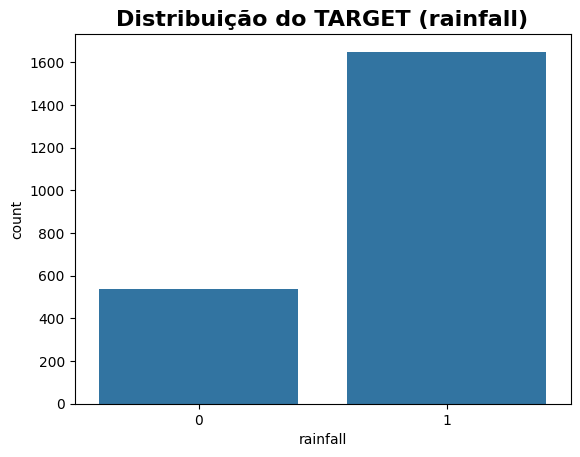

In [5]:
data_treino['rainfall'].value_counts()
sns.countplot(x='rainfall', data=data_treino)
plt.title('Distribuição do TARGET (rainfall)', fontsize=16, fontweight='bold')


## Correlação

----------------------------------------------------------------------------------------------------
Tabela de Correlação
----------------------------------------------------------------------------------------------------


,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
id,1.000000,0.153065,-0.008235,0.012590,0.014307,0.018708,0.006797,-0.029042,0.002226,-0.003022,-0.004223,0.020167,0.033674
day,0.153065,1.000000,0.005337,0.146294,0.153590,0.161475,0.137929,-0.074048,-0.048175,0.060936,0.024800,-0.000199,-0.000462
pressure,-0.008235,0.005337,1.000000,-0.800499,-0.816531,-0.814453,-0.817008,-0.119949,0.098600,-0.257163,-0.643293,0.266012,-0.049886
maxtemp,0.012590,0.146294,-0.800499,1.000000,0.982932,0.965529,0.906703,-0.072615,-0.289047,0.452387,0.662235,-0.354168,-0.079304
temparature,0.014307,0.153590,-0.816531,0.982932,1.000000,0.987150,0.933617,-0.025016,-0.249355,0.414019,0.668963,-0.342262,-0.049660
mintemp,0.018708,0.161475,-0.814453,0.965529,0.987150,1.000000,0.941342,0.009891,-0.219399,0.379497,0.663828,-0.328871,-0.026841
dewpoint,0.006797,0.137929,-0.817008,0.906703,0.933617,0.941342,1.000000,0.153390,-0.088446,0.249676,0.643073,-0.312179,0.081965
humidity,-0.029042,-0.074048,-0.119949,-0.072615,-0.025016,0.009891,0.153390,1.000000,0.584854,-0.541592,-0.012430,0.062285,0.454213
cloud,0.002226,-0.048175,0.098600,-0.289047,-0.249355,-0.219399,-0.088446,0.584854,1.000000,-0.805128,-0.127087,0.184698,0.641191
sunshine,-0.003022,0.060936,-0.257163,0.452387,0.414019,0.379497,0.249676,-0.541592,-0.805128,1.000000,0.272235,-0.241752,-0.555287


----------------------------------------------------------------------------------------------------
Matriz de Correlação
----------------------------------------------------------------------------------------------------


<Axes: title={'center': 'Matrix de Correlação'}>

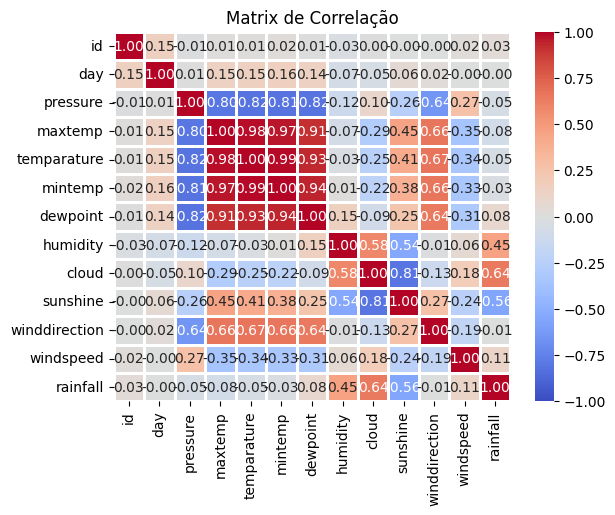

In [6]:
correlacao_tabela = data_treino.corr()
print('-'*100)
print('Tabela de Correlação')
print('-'*100)
display(correlacao_tabela)

print('-'*100)
print('Matriz de Correlação')
print('-'*100)

plt.title('Matrix de Correlação')
sns.heatmap(
    correlacao_tabela,
    annot=True,
    center= 0, vmin = -1, vmax = 1,
    linecolor= 'white',
    linewidths=1,
    fmt='.2f',
    cmap='coolwarm'
)

## Gráficos de Dispersão

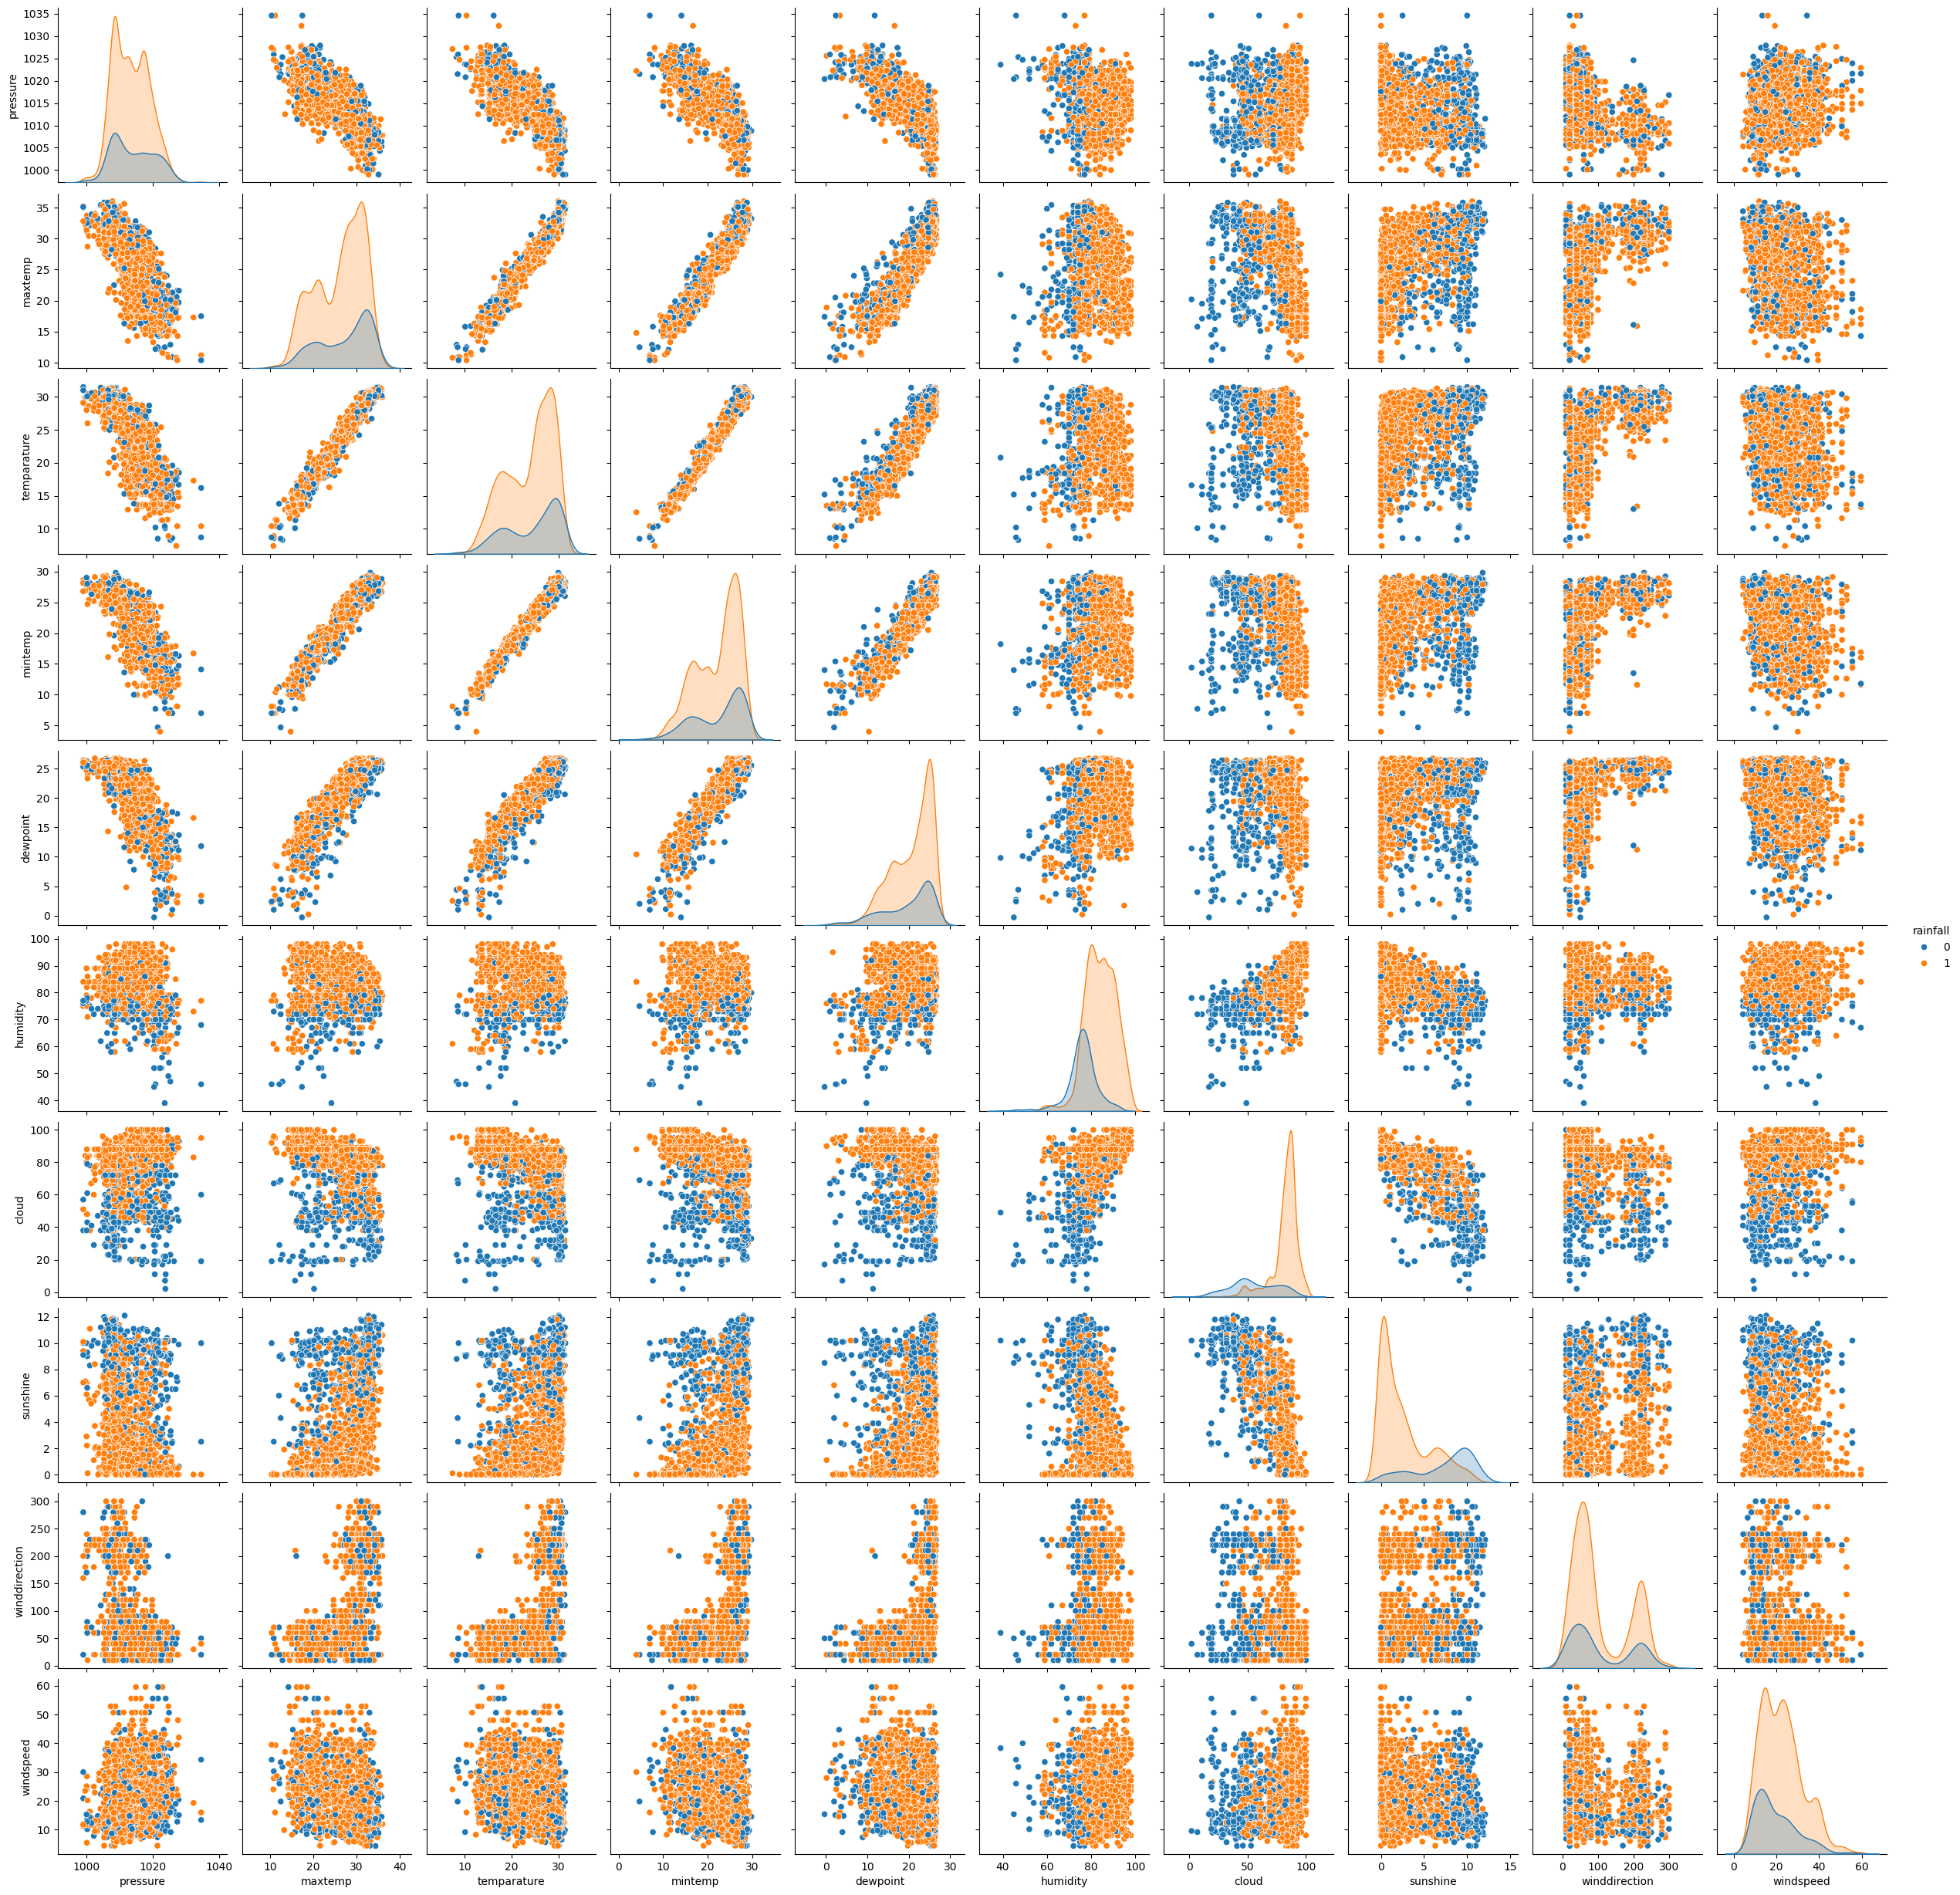

In [7]:
numerical = ['pressure', 'maxtemp', 'temparature', 'mintemp',
       'dewpoint', 'humidity', 'cloud', 'sunshine', 'winddirection',
       'windspeed']
sns.pairplot(data_treino, vars=numerical, hue='rainfall')

## Análises Separadas

### Análise 'Dewpoint'

<Axes: title={'center': 'Dewpoint Data Teste'}, ylabel='dewpoint'>

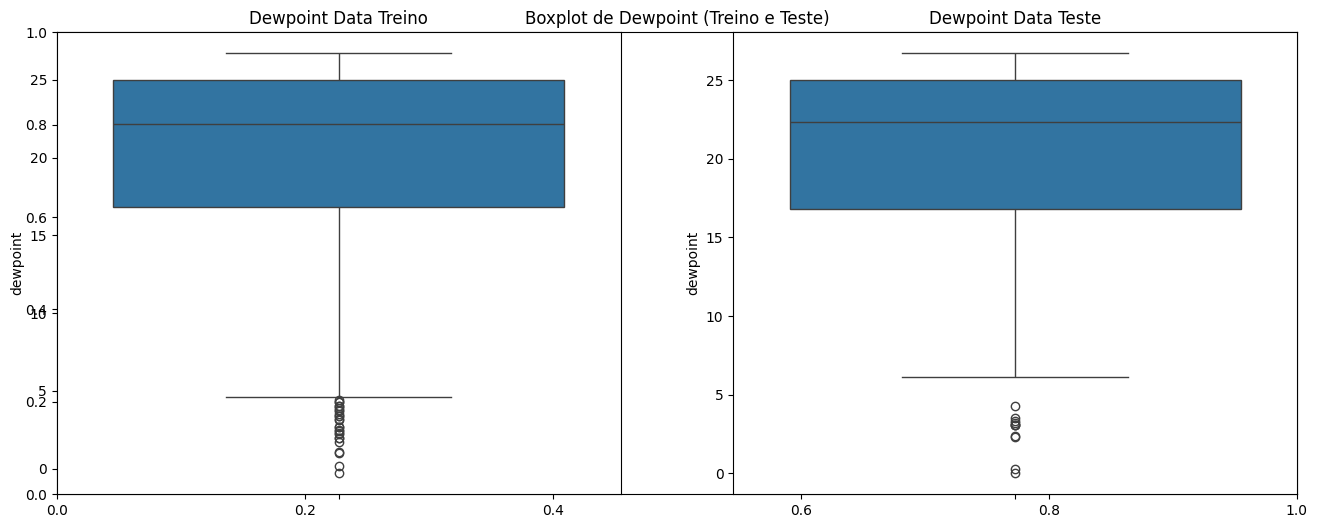

In [8]:
plt.figure(figsize = (16,6))
plt.title('Boxplot de Dewpoint (Treino e Teste)')

plt.subplot(1,2,1)
plt.title('Dewpoint Data Treino')
sns.boxplot(data=data_treino['dewpoint'])


plt.subplot(1,2,2)
plt.title('Dewpoint Data Teste')
sns.boxplot(data=data_teste['dewpoint'])

Text(0.5, 0, 'ID')

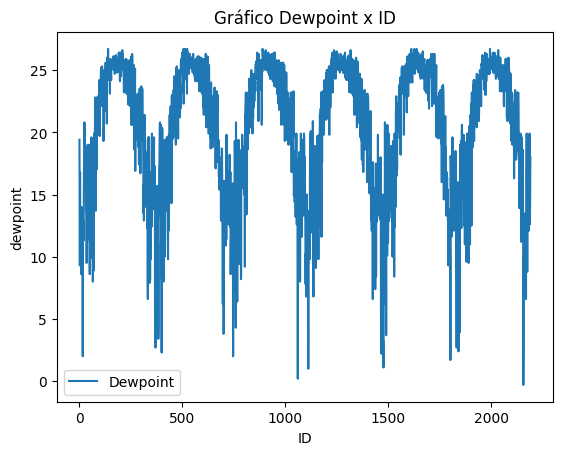

In [9]:
plt.title("Gráfico Dewpoint x ID")
sns.lineplot(data=data_treino['dewpoint'], label='Dewpoint')
plt.xlabel('ID')

Aprendizado: Trocar os valores negativos pela interpolação, tendo em vista o padrão ciclíco e outliers isolados de dewpoint .

### Redução de Colunas (Verificação com PCA)

#### Redução (temperature, maxtemp, mintemp, dewpoint)

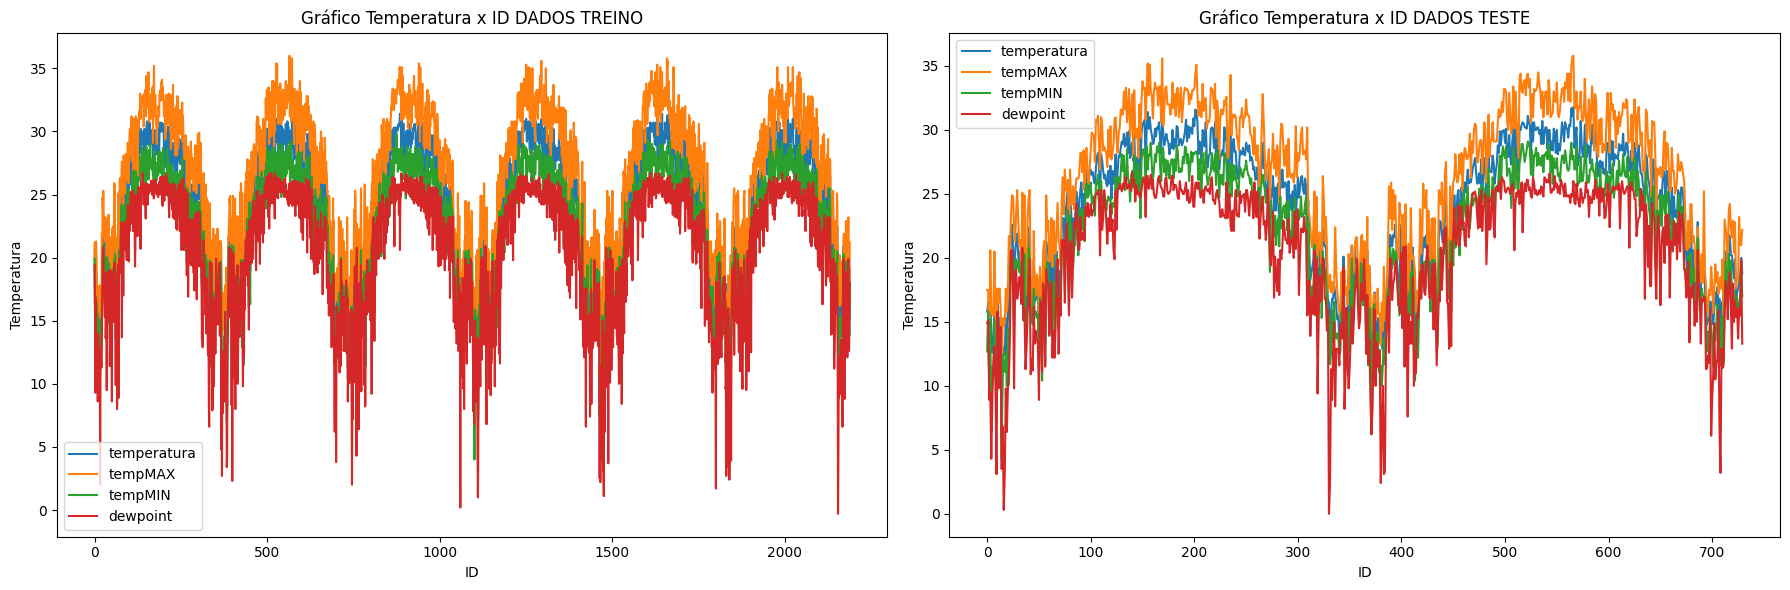

In [17]:
plt.figure(figsize=(18,6))                                            # Figura Geral - Matplotlib

plt.subplot(1,2,1)                                                    # Divisão figura geral -
plt.title("Gráfico Temperatura x ID DADOS TREINO")
sns.lineplot(data=data_treino['temparature'], label='temperatura')
sns.lineplot(data=data_treino['maxtemp'], label='tempMAX')
sns.lineplot(data=data_treino['mintemp'], label='tempMIN')
sns.lineplot(data=data_treino["dewpoint"], label = "dewpoint")
plt.xlabel('ID')
plt.ylabel('Temperatura')


plt.subplot(1,2,2)
plt.title("Gráfico Temperatura x ID DADOS TESTE")
sns.lineplot(data=data_teste['temparature'], label='temperatura')
sns.lineplot(data=data_teste['maxtemp'], label='tempMAX')
sns.lineplot(data=data_teste['mintemp'], label='tempMIN')
sns.lineplot(data=data_teste["dewpoint"], label = "dewpoint")
plt.xlabel('ID')
plt.ylabel('Temperatura')


plt.tight_layout()  # Evitar sobreposição
plt.show()          # Mostrar os Gráficos


Gráfico acima indica forte relação entre as colunas "maxtemp, temparature, mintemp e dewpoint"

In [24]:
# Selecionando as Colunas
colunas = ['maxtemp', 'temparature', 'mintemp', 'dewpoint']
reducao_treino = data_treino[colunas]
reducao_teste = data_teste[colunas]

# Normalizando os dados (PCA funciona melhor com dados padronizados)
scaler = StandardScaler()
reducao_scalada_treino = scaler.fit_transform(reducao_treino)
reducao_scalada_teste = scaler.fit_transform(reducao_teste)

# Aplicar PCA
pca_treino = PCA(n_components=1)  # Reduzindo para 1 componente
pca_teste = PCA(n_components=1)   # Reduzindo para 1 componente

reducao_unificada_treino = pca_treino.fit_transform(reducao_scalada_treino)
reducao_unificada_teste = pca_teste.fit_transform(reducao_scalada_teste)

# Criar um DataFrame com os novos componentes
temp_treino = pd.DataFrame(reducao_unificada_treino, columns=['PCA1'])
temp_teste = pd.DataFrame(reducao_unificada_teste, columns=['PCA1'])

print(f"Captura da Variância Data Treino = {pca_treino.explained_variance_ratio_}")
print(f"Captura da Variância Data Teste = {pca_teste.explained_variance_ratio_}")

Captura da Variância Data Treino = [0.96481135]
Captura da Variância Data Teste = [0.9632041]


Alta taxa de captura da variância de dados é um forte indicação(Dados Treino e Teste)

Conclusão: Unificação de Maxtemp, Temparature, MinTemp e Dewpoint com PCA é possível, captura de +-96% de variância de dados

#### Outras Reduções

In [29]:
# Selecionando as Colunas
colunas_1 = ['winddirection', 'windspeed']
colunas_2 = ['id', 'day']
colunas_3 = ['humidity', 'cloud']

reducao_1 = data_treino[colunas_1]
reducao_2 = data_treino[colunas_2]
reducao_3 = data_treino[colunas_3]

# Normalizando os dados (PCA funciona melhor com dados padronizados)
scaler = StandardScaler()
reducao_scalada_1 = scaler.fit_transform(reducao_1)
reducao_scalada_2 = scaler.fit_transform(reducao_2)
reducao_scalada_3 = scaler.fit_transform(reducao_3)

# Aplicar PCA
pca_1 = PCA(n_components=1)  # Reduzindo para 1 componentes
pca_2 = PCA(n_components=1)  # Reduzindo para 1 componentes
pca_3 = PCA(n_components=1)  # Reduzindo para 1 componentes

reducao_unificada_1 = pca_1.fit_transform(reducao_scalada_1)
reducao_unificada_2 = pca_2.fit_transform(reducao_scalada_2)
reducao_unificada_3 = pca_3.fit_transform(reducao_scalada_3)

# Criar um DataFrame com os novos componentes
temp_1 = pd.DataFrame(reducao_unificada_1, columns=['PCA1'])
temp_2 = pd.DataFrame(reducao_unificada_2, columns=['PCA1'])
temp_3 = pd.DataFrame(reducao_unificada_3, columns=['PCA1'])

print(f"Captura da Variância Colunas [winddirection, windspeed].....{pca_1.explained_variance_ratio_}")
print(f"Captura da Variância Colunas [id, day]......................{pca_2.explained_variance_ratio_}")
print(f"Captura da Variância Colunas [humidity, cloud]..............{pca_3.explained_variance_ratio_}")

Captura da Variância Colunas [winddirection, windspeed].....[0.59620846]
Captura da Variância Colunas [id, day]......................[0.57653256]
Captura da Variância Colunas [humidity, cloud]..............[0.79242717]


Captura da Variância não Satisfatórias